<a href="https://colab.research.google.com/github/bu11ymaguire/studying/blob/main/ReinforcementLearning/pratice_DeZero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


class Renderer:
    def __init__(self, reward_map, goal_state, wall_state):
        self.reward_map = reward_map
        self.goal_state = goal_state
        self.wall_state = wall_state
        self.ys = len(self.reward_map)
        self.xs = len(self.reward_map[0])

        self.ax = None
        self.fig = None
        self.first_flg = True

    def set_figure(self, figsize=None):
        fig = plt.figure(figsize=figsize)
        self.ax = fig.add_subplot(111)
        ax = self.ax
        ax.clear()
        ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
        ax.set_xticks(range(self.xs))
        ax.set_yticks(range(self.ys))
        ax.set_xlim(0, self.xs)
        ax.set_ylim(0, self.ys)
        ax.grid(True)

    def render_v(self, v=None, policy=None, print_value=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax

        if v is not None:
            color_list = ['red', 'white', 'green']
            cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                'colormap_name', color_list)

            # dict -> ndarray
            v_dict = v
            v = np.zeros(self.reward_map.shape)
            for state, value in v_dict.items():
                v[state] = value

            vmax, vmin = v.max(), v.min()
            vmax = max(vmax, abs(vmin))
            vmin = -1 * vmax
            vmax = 1 if vmax < 1 else vmax
            vmin = -1 if vmin > -1 else vmin

            ax.pcolormesh(np.flipud(v), cmap=cmap, vmin=vmin, vmax=vmax)

        for y in range(ys):
            for x in range(xs):
                state = (y, x)
                r = self.reward_map[y, x]
                if r != 0 and r is not None:
                    txt = 'R ' + str(r)
                    if state == self.goal_state:
                        txt = txt + ' (GOAL)'
                    ax.text(x+.1, ys-y-0.9, txt)

                if (v is not None) and state != self.wall_state:
                    if print_value:
                        offsets = [(0.4, -0.15), (-0.15, -0.3)]
                        key = 0
                        if v.shape[0] > 7: key = 1
                        offset = offsets[key]
                        ax.text(x+offset[0], ys-y+offset[1], "{:12.2f}".format(v[y, x]))

                if policy is not None and state != self.wall_state:
                    actions = policy[state]
                    max_actions = [kv[0] for kv in actions.items() if kv[1] == max(actions.values())]

                    # Corrected arrows and offsets to match GridWorld's action_move_map:
                    # 0: UP, 1: DOWN, 2: RIGHT, 3: LEFT
                    arrows = ["↑", "↓", "→", "←"]
                    offsets = [(0, 0.1), (0, -0.1), (0.1, 0), (-0.1, 0)]
                    for action in max_actions:
                        arrow = arrows[action]
                        offset = offsets[action]
                        if state == self.goal_state:
                            continue
                        ax.text(x+0.45+offset[0], ys-y-0.5+offset[1], arrow)

                if state == self.wall_state:
                    ax.add_patch(plt.Rectangle((x,ys-y-1), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
        plt.show()

    def render_q(self, q, show_greedy_policy=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax
        action_space = [0, 1, 2, 3]

        qmax, qmin = max(q.values()), min(q.values())
        qmax = max(qmax, abs(qmin))
        qmin = -1 * qmax
        qmax = 1 if qmax < 1 else qmax
        qmin = -1 if qmin > -1 else qmin


        color_list = ['red', 'white', 'green']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
            'colormap_name', color_list)

        for y in range(ys):
            for x in range(xs):
                for action in action_space:
                    state = (y, x)
                    r = self.reward_map[y, x]
                    if r != 0 and r is not None:
                        txt = 'R ' + str(r)
                        if state == self.goal_state:
                            txt = txt + ' (GOAL)'
                        ax.text(x+.05, ys-y-0.95, txt)

                    if state == self.goal_state:
                        continue

                    tx, ty = x, ys-y-1

                    # Corrected action_map and offset_map to match GridWorld's action_move_map:
                    # 0: UP, 1: DOWN, 2: RIGHT, 3: LEFT
                    action_map = {
                        0: ((0.5+tx, 0.5+ty), (tx+1, ty+1), (tx, ty+1)), # Up triangle
                        1: ((tx, ty), (tx+1, ty), (tx+0.5, ty+0.5)),    # Down triangle
                        2: ((0.5+tx, 0.5+ty), (tx+1, ty), (tx+1, ty+1)), # Right triangle (originally for action 3)
                        3: ((tx, ty), (tx+0.5, ty+0.5), (tx, ty+1)),    # Left triangle (originally for action 2)
                    }
                    offset_map = {
                        0: (0.1, 0.8),
                        1: (0.1, 0.1),
                        2: (0.4, 0.4), # Right offset (originally for action 3)
                        3: (-0.2, 0.4), # Left offset (originally for action 2)
                    }
                    if state == self.wall_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
                    elif state in self.goal_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0., 1., 0., 1.)))
                    else:

                        tq = q[(state, action)]
                        color_scale = 0.5 + (tq / qmax) / 2  # normalize: 0.0-1.0

                        poly = plt.Polygon(action_map[action],fc=cmap(color_scale))
                        ax.add_patch(poly)

                        offset= offset_map[action]
                        ax.text(tx+offset[0], ty+offset[1], "{:12.2f}".format(tq))
        plt.show()

        if show_greedy_policy:
            policy = {}
            for y in range(self.ys):
                for x in range(self.xs):
                    state = (y, x)
                    qs = [q[state, action] for action in range(4)]  # action_size
                    max_action = np.argmax(qs)
                    probs = {0:0.0, 1:0.0, 2:0.0, 3:0.0}
                    probs[max_action] = 1
                    policy[state] = probs
            self.render_v(None, policy)

In [15]:
import numpy as np

class GridWorld:
  def __init__(self):
    self.action_space = [0,1,2,3]
    self.action_meaning = {
        0: "UP",
        1: "DOWN",
        2: "LEFT",
        3: "RIGHT"
    }

    self.reward_map = np.array(
        [[0,0,0,1.0],
         [0,None,0,-1.0],
            [0,0,0,0]
        ]
    )

    self.goal_state = (0,3) #목표 지점
    self.wall_state = (1,1) #벽
    self.start_state = (2,0) #시작 지점
    self.agent_state = self.start_state

  @property
  def height(self):
    return len(self.reward_map)

  @property
  def width(self):
    return len(self.reward_map[0])

  @property
  def shape(self):
    return self.reward_map.shape

  def actions(self):
    return self.action_space

  def states(self):
    for h in range(self.height):
      for w in range(self.width):
        yield(h,w)

  def next_state(self, state, action):
    action_move_map = [(-1,0),(1,0),(0,1),(0,-1)]
    move = action_move_map[action]
    next_state = (state[0]+ move[0],state[1] + move[1])
    ny, nx = next_state

    if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height: #이동하게 될 위치가 영역의 밖인 경우?
      next_state = state
    elif next_state == self.wall_state: #이동하게 될 위치가 벽인 경우
      next_state = state

    return next_state

  def reward(self, state, action, next_state):
    return self.reward_map[next_state]

  def render_v(self, v=None, policy=None, print_value=True):
        renderer = gridworld_render.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_v(v, policy, print_value)

In [16]:
# Monkey-patching the render_v method to fix NameError
import types
def fixed_render_v(self, v=None, policy=None, print_value=True):
    # This version directly calls Renderer instead of gridworld_render.Renderer
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_v(v, policy, print_value)

In [1]:
!pip install dezero

In [2]:
import numpy as np

# ⬇️ 이 줄을 추가하세요! (dezero가 찾을 수 있도록 np.int를 int로 연결)
np.int = int  

from dezero import Variable
import dezero.functions as F

np.random.seed(37)

In [3]:
x = np.random.rand(100,1)
y = np.sin(2 * np.pi * x) + np.random.rand(100,1)

#INIT
I, H, O = 1, 10 ,1 # 입력층, 은닉층, 출력층
W1 = Variable(0.01 * np.random.randn(I,H))
b1 = Variable(np.zeros(H))
W2 = Variable(0.01 * np.random.randn(H, O))
b2 = Variable(np.zeros(O))

def predict(x):
    y = F.linear(x,W1,b1)
    y = F.sigmoid(y)
    y = F.linear(y, W2, b2)
    return y

lr = 0.2
iters = 10000

for i in range(iters):
    y_pred = predict(x)
    loss = F.mean_squared_error(y, y_pred)
    
    W1.cleargrad()
    b1.cleargrad()
    W2.cleargrad()
    b2.cleargrad()

    loss.backward()

    W1.data -= lr * W1.grad.data
    b1.data -= lr * b1.grad.data
    W2.data -= lr * W2.grad.data
    b2.data -= lr * b2.grad.data

    if i % 1000 == 0:
        print(f"{i}:{loss.data}")

0:0.7352033286321561
1000:0.31253905224859885
2000:0.3114427702956396
3000:0.3099498790602519
4000:0.30719092920918567
5000:0.29832545933531074
6000:0.2570601581220487
7000:0.13321481076945466
8000:0.07836149847580075
9000:0.07589156236538247


In [4]:
import numpy as np
np.int = int
import dezero.layers as L

linear = L.Linear(10)

batch_size, input_size = 100, 5
x = np.random.randn(batch_size, input_size)
y = linear(x)

print(f"y shape:{y.shape}")
print(f"x shape:{x.shape}")

for param in linear.params():
    print(param.name, param.shape)

y shape:(100, 10)
x shape:(100, 5)
W (5, 10)
b (10,)


In [5]:
from dezero import Model
import dezero.layers as L
import dezero.functions as F

class TwoLayerNet(Model):
    def __init__(self, hidden_size, out_size):
        super().__init__()
        self.l1 = L.Linear(hidden_size)
        self.l2 = L.Linear(out_size)

    def forward(self, x):
        y = F.ReLU(self.l1(x))
        y = self.l2(y)
        return y     

In [6]:
model = TwoLayerNet(10,1)

for param in model.params():
    print(param)

model.cleargrads()    

variable(None)
variable([0. 0. 0. 0. 0. 0. 0. 0. 0. 0.])
variable(None)
variable([0.])


In [7]:
class TwoLayerNet(Model):
    def __init__(self, hidden_size, out_size):
        super().__init__()
        self.l1 = L.Linear(hidden_size)
        self.l2 = L.Linear(out_size)

    def forward(self, x):
        y = F.sigmoid(self.l1(x))
        y = self.l2(y)
        return y    

np.random.seed(37)
x = np.random.rand(100,1)
y = np.sin(2 * np.pi * x) + np.random.rand(100,1)

lr = 0.2
iters = 10000

model = TwoLayerNet(10,1)

for i in range(iters):
    y_pred = model.forward(x)
    loss = F.mean_squared_error(y, y_pred)

    model.cleargrads()
    loss.backward()

    for p in model.params():
        p.data -= lr * p.grad.data

    if i % 1000 == 0:
        print(loss)    

variable(1.0945114400508624)
variable(0.31160560053699426)
variable(0.3096941076772005)
variable(0.3057316552774115)
variable(0.291816257341373)
variable(0.20918484731639544)
variable(0.08466935173497074)
variable(0.14050294846260158)
variable(0.07485435352926727)
variable(0.07459132398384406)


In [8]:
from dezero import optimizers

np.random.seed(37)
x = np.random.rand(100,1)
y = np.sin(2 * np.pi *x) + np.random.rand(100,1)
lr = 0.2
iters = 10000

model = TwoLayerNet(10,1)
optimizer = optimizers.SGD(lr)
optimizer.setup(model)

for i in range(iters):
    y_pred = model(x)
    loss = F.mean_squared_error(y, y_pred)

    model.cleargrads()
    loss.backward()

    optimizer.update()
    if i % 1000:
        print(loss)

variable(0.6449284676394226)
variable(0.5351060460748999)
variable(0.5050127757929613)
variable(0.49339463705392)
variable(0.48607645392013393)
variable(0.4798741416791068)
variable(0.47406143787592364)
variable(0.4684699926293819)
variable(0.4630571878599538)
variable(0.4578093871404618)
variable(0.4527196863399213)
variable(0.44778296496366876)
variable(0.4429946804914598)
variable(0.4383506010562481)
variable(0.43384671696048493)
variable(0.4294792107687946)
variable(0.4252444364953671)
variable(0.42113890206712895)
variable(0.4171592560034744)
variable(0.4133022734923998)
variable(0.4095648458168926)
variable(0.4059439682376134)
variable(0.402436731843824)
variable(0.3990403138645135)
variable(0.3957519702639691)
variable(0.3925690295276102)
variable(0.38948888573863516)
variable(0.3865089930194703)
variable(0.3836268613730016)
variable(0.3808400523173849)
variable(0.378146174393886)
variable(0.37554288105648737)
variable(0.37302786741948135)
variable(0.3705988678192344)
variable(0

# 3 x 4 그리드 월드를 원핫 인코딩으로 매핑하기

In [9]:
import numpy as np

def one_hot(state):

    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)

    y,x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0

    return vec[np.newaxis, :]

state = (2, 0)
x = one_hot(state)

print(x.shape)
print(x)

(1, 12)
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


## 테이블 방식의 Q함수

In [10]:
from collections import defaultdict

Q = defaultdict(lambda: 0)
state = (2,0)
action = 0

print(Q[state,action])

0


## 신경망 구현
- 상태와 행동을 입력받아서 스칼라를 출력 vs 상태만을 입력받아서 이에 대응되는 행동의 개수만큼 Q 함수를 출력
- 전자는 행동 후보의 수만큼 신경망을 순전파해서 max_a_Q(s,a)를 구해야 된다.

In [12]:
from dezero import Model
import dezero.functions as F
import dezero.layers as L

class QNet(Model):
    def __init__(self):
        super().__init__()
        self.l1 = L.Linear(100)
        self.l2 = L.Linear(4)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        return x

qnet = QNet()

state = (2,0)
state = one_hot(state)

qs = qnet(state)
print(qs.shape)

(1, 4)


In [18]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        self.qnet = QNet()
        self.optimizer = optimizers.SGD(self.lr)
        self.optimizer.setup(self.qnet)

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)

        else:
            qs = self.qnet(state)
            return qs.data.argmax()

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q = np.zeros(1) # 목표 상태에서의 Q 함수는 항상 0
        else:
            next_qs = self.qnet(next_state)
            next_q = next_qs.max(axis = 1)
            next_q.unchain() # next_q를 역전파 대상에서 제외
        '''
        다음과 같이 구현도 가능.
        done = int(done)
        next_qs = self.qnet(next_state)
        next_q = next_qs.max(axis = 1)
        next_q.unchain()
        '''    
        target = self.gamma * next_q + reward
        qs = self.qnet(state)
        q = qs[:,action]
        loss = F.mean_squared_error(target, q)

        self.qnet.cleargrads()
        loss.backward()
        self.optimizer.update()

        return loss.data                

In [20]:
import types
import numpy as np # Ensure numpy  available for np.argmax

env = GridWorld()
agent = QLearningAgent()
# Monkey-patching GridWorld instance with reset and step methods
def reset_method(self):
    self.agent_state = self.start_state
    return self.agent_state

def step_method(self, action):
    state = self.agent_state
    next_s = self.next_state(state, action)
    r = self.reward(state, action, next_s)
    done = (next_s == self.goal_state)
    self.agent_state = next_s
    return next_s, r, done

# Definition of fixed_render_v, copied from cell vQRb2f3tM7kE
def fixed_render_v(self, v=None, policy=None, print_value=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_v(v, policy, print_value)

# Define fixed_render_q to render Q-values using the Renderer class
def fixed_render_q(self, q, show_greedy_policy=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_q(q, show_greedy_policy)

env.reset = types.MethodType(reset_method, env)
env.step = types.MethodType(step_method, env)
env.render_v = types.MethodType(fixed_render_v, env) # Apply the fix for render_v
env.render_q = types.MethodType(fixed_render_q, env) # Apply the fix for render_q

# Redefine greedy_probs within this cell to use np.argmax, as it's used by QLearningAgent
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs) # Use np.argmax for lists
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

episodes = 1000
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)

        loss = agent.update(state, action, reward, next_state, done)
        total_loss += loss
        cnt += 1
        state = next_state
    average_loss = total_loss / cnt
    loss_history.append(average_loss)    

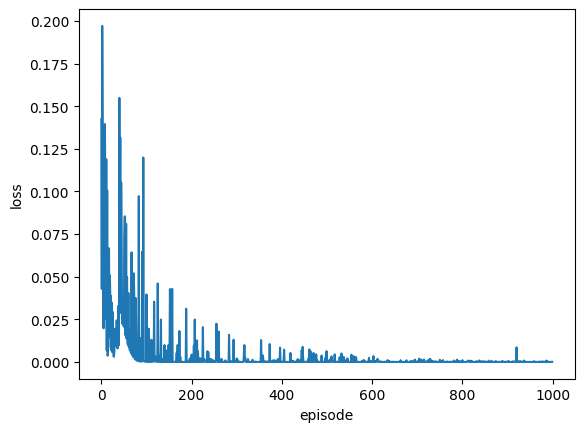

In [21]:
plt.xlabel('episode')
plt.ylabel('loss')
plt.plot(range(len(loss_history)), loss_history)
plt.show()

/tmp/ipython-input-3577325236.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Q[state, action] = float(q.data)


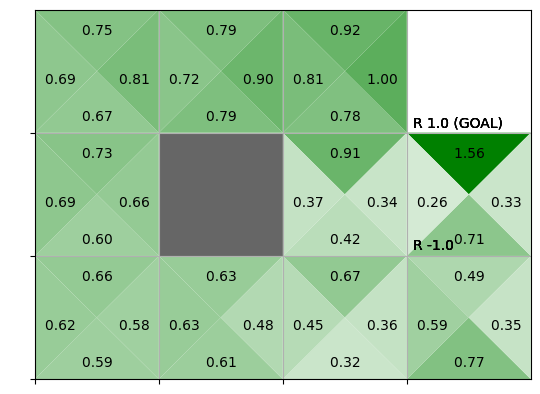

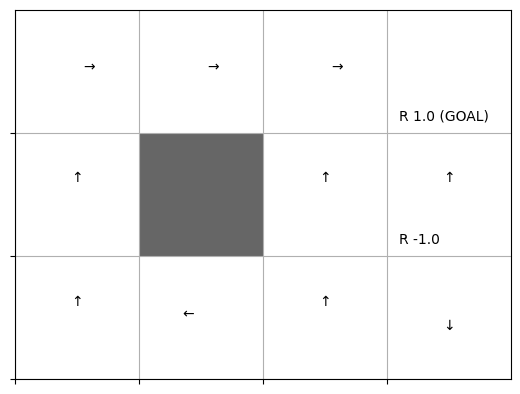

In [22]:
Q = {}
for state in env.states():
    for action in env.action_space:
        q = agent.qnet(one_hot(state))[:, action]
        Q[state, action] = float(q.data)
env.render_q(Q)